#WEEK 3 EDA for Google Apps Review H&M
Mirza Fathi Taufiqurrahman 5026231105

In [1]:
!pip install google-play-scraper
!pip install nltk
!pip install sastrawi
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.4 MB/s eta 0:00:00


In [3]:
import pandas as pd

from google_play_scraper import Sort, reviews_all
import pandas as pd

app_id = 'com.hm.gillcaptital'

result = reviews_all(
    app_id,
    sleep_milliseconds=1000,
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

df = pd.DataFrame(result)

file_name = "semua_hnm.csv"
df.to_csv(file_name, index=False)

# Read the Excel file (only if the file exists)
df_hnm = pd.read_csv("semua_hnm.csv")

# Display the first few rows
df_hnm.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7e274293-bff8-409b-812d-3d47f597f854,LEGASUS GAMING,https://play-lh.googleusercontent.com/a/ACg8oc...,pengiriman lama kali bisa sampai 10 hari lebih...,1,0,21.3.8-PROD,2026-03-26 22:48:28,NaN,NaN,21.3.8-PROD
1,f1d93333-d030-40c7-a595-d9e3363805d7,Vanda Selabica,https://play-lh.googleusercontent.com/a-/ALV-U...,apk lemot bgt buset,1,0,21.3.5-PROD,2026-03-05 01:07:34,NaN,NaN,21.3.5-PROD
2,01d442aa-cae2-4ace-98d7-1a493d1f4309,Rizqi Alkhairi,https://play-lh.googleusercontent.com/a/ACg8oc...,lu mau internet sekencang apa?,1,0,21.3.5-PROD,2026-03-04 14:48:04,NaN,NaN,21.3.5-PROD
3,e1ab8869-4a60-4965-8f6f-a04337fd3a65,Muhammad Amin,https://play-lh.googleusercontent.com/a/ACg8oc...,"barangnya pas dihati , harga nya pas di dompet",5,1,21.2.1-PROD,2026-03-04 10:24:31,NaN,NaN,21.2.1-PROD
4,29d6a939-319a-444a-a5a4-e90e60149f19,nzw Ghrsy,https://play-lh.googleusercontent.com/a/ACg8oc...,"kenapa susah mau mau isi tanggal lahir juga, a...",3,0,21.3.1-PROD,2026-02-10 03:57:38,NaN,NaN,21.3.1-PROD


# Exploratory Data Analysis (EDA) of H&M - Thailand&Indonesia

## 1. Install Necessary Packages

In [4]:
!pip install pandas matplotlib seaborn nltk

## 2. Import Required Libraries


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string

## 3. Download Stopwords

```python
nltk.download('stopwords')
from nltk.corpus import stopwords
```

## 3. Download Sastrawi

In [11]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')


# Create stemmer and lemmatizer objects
factory = StemmerFactory()
stemmer = factory.create_stemmer()
lemmatizer = WordNetLemmatizer()

# Get Indonesian stopwords
indonesian_stopwords = set(stopwords.words('indonesian'))

def clean_text(text):
    # Case lowering
    text = text.lower()

    # Punctuation removal
    text = re.sub(r'[^ -⁯⸀-⹿\s\w\d]', '', text) # Remove punctuation but keep alphanumeric and spaces

    # Number removal
    text = re.sub(r'\d+', '', text)

    # Stemming
    text = stemmer.stem(text)

    # Lemmatization (requires a part-of-speech tag for optimal results, using 'v' for verb as a default)
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word, 'v') for word in words]
    text = ' '.join(lemmatized_words)

    # Stopword removal
    words = text.split()
    filtered_words = [word for word in words if word not in indonesian_stopwords]
    text = ' '.join(filtered_words)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply the cleaning function to the 'review' column
df_hnm['cleaned_review'] = df_hnm['content'].apply(clean_text)

# Display the DataFrame with the cleaned reviews
print(df_hnm[['content', 'cleaned_review']])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                                content  \
0     pengiriman lama kali bisa sampai 10 hari lebih...   
1                                   apk lemot bgt buset   
2                        lu mau internet sekencang apa?   
3        barangnya pas dihati , harga nya pas di dompet   
4     kenapa susah mau mau isi tanggal lahir juga, a...   
...                                                 ...   
2025  Lemod dan tergembel gabisa di akses setelahh d...   
2026                                   Lemot bgt parahh   
2027                         Kok gabisa cek orderan ya?   
2028                                             Mantap   
2029           Untuk bulan kelahiran belom comlited bos   

                                         cleaned_review  
0                              kirim kali klo gw protes  
1                                     apk lot bgt buset  
2                                   lu internet kencang  
3                  barang pas hati harga nya pas dompet  
4

## 5. Data Overview


In [12]:
# Convert 'at' column to datetime format
df_hnm['at'] = pd.to_datetime(df_hnm['at'])

# Display dataset info and first few rows
df_hnm.info()
df_hnm.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              2030 non-null   object        
 1   userName              2030 non-null   object        
 2   userImage             2030 non-null   object        
 3   content               2030 non-null   object        
 4   score                 2030 non-null   int64         
 5   thumbsUpCount         2030 non-null   int64         
 6   reviewCreatedVersion  1788 non-null   object        
 7   at                    2030 non-null   datetime64[ns]
 8   replyContent          0 non-null      float64       
 9   repliedAt             0 non-null      float64       
 10  appVersion            1788 non-null   object        
 11  cleaned_review        2030 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 190.4+ K

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,cleaned_review
0,7e274293-bff8-409b-812d-3d47f597f854,LEGASUS GAMING,https://play-lh.googleusercontent.com/a/ACg8oc...,pengiriman lama kali bisa sampai 10 hari lebih...,1,0,21.3.8-PROD,2026-03-26 22:48:28,NaN,NaN,21.3.8-PROD,kirim kali klo gw protes
1,f1d93333-d030-40c7-a595-d9e3363805d7,Vanda Selabica,https://play-lh.googleusercontent.com/a-/ALV-U...,apk lemot bgt buset,1,0,21.3.5-PROD,2026-03-05 01:07:34,NaN,NaN,21.3.5-PROD,apk lot bgt buset
2,01d442aa-cae2-4ace-98d7-1a493d1f4309,Rizqi Alkhairi,https://play-lh.googleusercontent.com/a/ACg8oc...,lu mau internet sekencang apa?,1,0,21.3.5-PROD,2026-03-04 14:48:04,NaN,NaN,21.3.5-PROD,lu internet kencang
3,e1ab8869-4a60-4965-8f6f-a04337fd3a65,Muhammad Amin,https://play-lh.googleusercontent.com/a/ACg8oc...,"barangnya pas dihati , harga nya pas di dompet",5,1,21.2.1-PROD,2026-03-04 10:24:31,NaN,NaN,21.2.1-PROD,barang pas hati harga nya pas dompet
4,29d6a939-319a-444a-a5a4-e90e60149f19,nzw Ghrsy,https://play-lh.googleusercontent.com/a/ACg8oc...,"kenapa susah mau mau isi tanggal lahir juga, a...",3,0,21.3.1-PROD,2026-02-10 03:57:38,NaN,NaN,21.3.1-PROD,susah isi tanggal lahir angka ga sesuai ga pdh...


## 6. Missing Values Analysis


In [13]:
missing_values = df_hnm.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion     242
at                         0
replyContent            2030
repliedAt               2030
appVersion               242
cleaned_review             0
dtype: int64


## 7. Review Score Distribution

/tmp/ipykernel_3306/2592593602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_hnm['score'], palette="viridis")


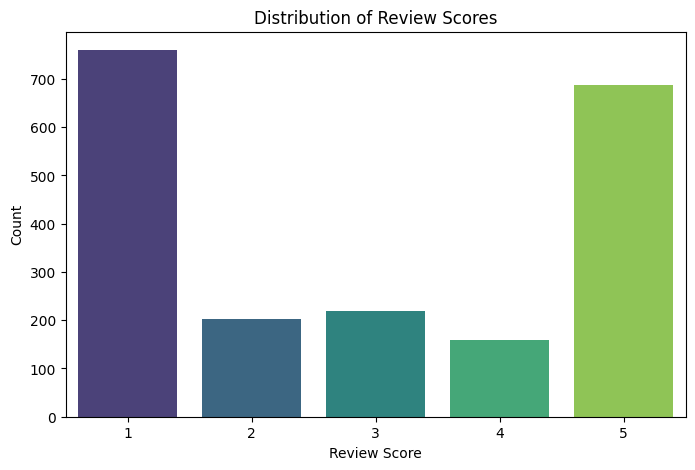

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_hnm['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

## 8. Review Trends Over Time


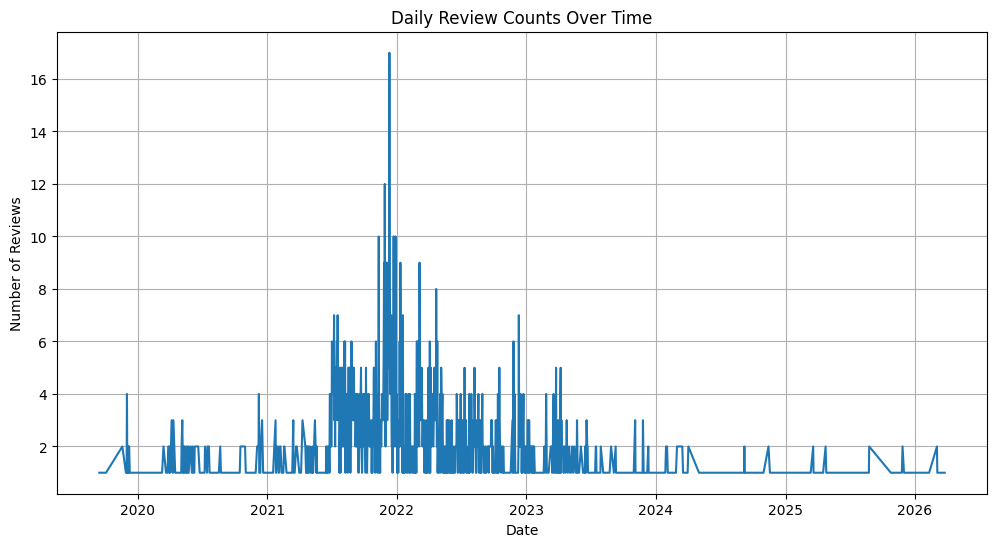

In [15]:
df_hnm['review_date'] = df_hnm['at'].dt.date
review_trend = df_hnm.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

## 9. Word Frequency Analysis

In [19]:
stop_words = set(stopwords.words('indonesian'))

# Add colloquial stopwords to the set
stop_words.add('yg')
stop_words.add('ga')
stop_words.add('bgt')
stop_words.add('aja')
stop_words.add('nya')
stop_words.add('gk')
stop_words.add('gitu')
stop_words.add('loh')
stop_words.add('sih')
stop_words.add('udah')

# Combine all review text
all_reviews = " ".join(df_hnm['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenization and filtering words
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)

Most Common Words in Reviews:
           Word  Frequency
0      aplikasi        274
1         lemot        224
2         bagus        175
3        banget        143
4   aplikasinya        139
5        barang        134
6           gak        132
7          good        132
8       belanja        107
9      thailand        100
10        susah         93
11          app         86
12       tolong         79
13          apk         78
14           hm         71
15    indonesia         68
16          out         67
17           ya         64
18         suka         63
19          pas         61


## 10. Word Cloud Generation
Visualizing the most frequent words.

In [ ]:
!pip install wordcloud

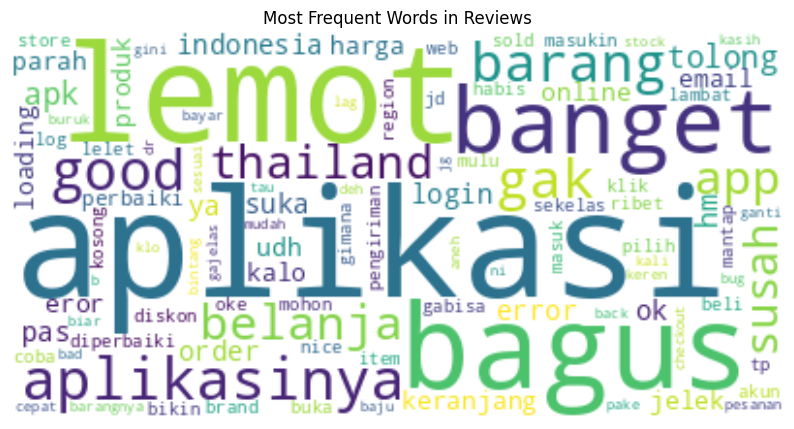

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join the filtered words to create a single string
long_string = " ".join(filtered_words)

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=100, contour_width=3, contour_color='steelblue', collocations=False)

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Reviews')
plt.show()